# Fase 1 · Trilha A — Gradient Boosting

A fase de modelagem testa três metodologias para o mesmo problema — **gradient boosting**, **rede neural** e **rede convolucional** —, todas avaliadas na mesma régua. Esta primeira trilha estabelece o gradient boosting como *baseline* de referência.

## Objetivo

A fase de entendimento especificou o modelo: prever o **quantil 95 da demanda diária** de cada SKU, com preditores restritos ao que se conhece antes do dia, avaliado por uma métrica que penalize mais a subestimação. Esta fase constrói o **primeiro modelo** que atende a essa especificação, seguindo a metodologia que venceu a competição de referência da área.

**Para que serve a previsão.** O objetivo final não é o número em si, é o **pedido de reposição**. A previsão do quantil 95 vira a quantidade a pedir, e esse pedido tem uma meta geométrica clara, herdada da fase 0c: **achatar o dente de serra**. Um dente achatado significa um ciclo de estoque baixo e regular — pouco capital parado no topo — cujo **vale nunca cruza a demanda** (nada de ruptura) e ainda guarda uma **margem de segurança** acima dela. Prever a média deixaria o vale no meio da demanda, rompendo metade dos dias; prever o quantil 95 põe o vale no lugar certo. É essa a ligação entre o modelo e a operação.

## A referência: competição M5

> **Principal:** Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2022). *The M5 accuracy competition.* **International Journal of Forecasting**, 38(4), 1346–1364. [doi](https://doi.org/10.1016/j.ijforecast.2021.11.013) · [preprint (PDF)](referencias/M5-accuracy-competition_preprint.pdf)
>
> **Secundária:** Ke, G. et al. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree.* NeurIPS 30. [PDF](referencias/Ke2017_LightGBM_NeurIPS.pdf)
>
> Fichas em [`referencias/M5-accuracy-competition.md`](referencias/M5-accuracy-competition.md).

A M5 previu as vendas diárias do Walmart — um painel de `loja × produto × dia` **de estrutura quase idêntica à deste projeto**. As **50 melhores submissões superaram o melhor benchmark em mais de 14%** (22,4% na vencedora), todas com gradient boosting. Quatro achados do artigo definem esta trilha:

| achado da M5 | como aplico aqui |
|---|---|
| **Gradient boosting domina** — quase todas as soluções de topo usaram LightGBM | GBM é a **Trilha A**: o *baseline* forte a ser batido |
| **Cross-learning vence** — um modelo global supera modelos por série | treino **um GBM sobre os 100 SKUs juntos** |
| **Avaliação escalada e temporal** — WRMSSE, teste na janela final | uso **RMSSE** com **split temporal** e *naïve* como piso |
| **A incerteza importa** — pinball loss por quantil | modelo de **quantil 95 com pinball loss** |

## O que é a "Trilha A"

Gradient boosting é o **benchmark a bater**, não necessariamente o modelo final: qualquer modelo mais complexo só se justifica se superar este número — do contrário, entregou complexidade, não resultado.

> **Nota de implementação.** A M5 usou LightGBM. Este ambiente não o tem, mas o `HistGradientBoostingRegressor` do scikit-learn é da **mesma família** (gradient boosting sobre histogramas), com suporte nativo a categóricas e à **perda quantílica** (*pinball*) — exatamente o que a fase de entendimento pediu.

## 1. Atributos admissíveis e partição temporal

Seguindo a restrição da fase 0a, o modelo usa apenas variáveis conhecidas antes do dia: categoria, loja, estação, clima, epidemia, promoção, desconto e calendário. Ficam de fora `estoque`, `vendas` e `pedidos` (vazamento). Sobre essa base honesta, `lags` e o preço são preparados para *teste* — não assumidos —, pois há motivo para desconfiar de ambos (seções 4 e 5).

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
PALETA = "Set2"
QUANTIL = 0.95          # nível de serviço alvo (fase 0c)
HORIZONTE = 120         # dias finais reservados para teste (janela à frente, como na M5)

caminho = next(arq for pasta in [Path("."), Path("projeto"), Path("..")]
               for arq in sorted(pasta.glob("sales_data*.csv")))
nomes = {"Date": "data", "Store ID": "loja", "Product ID": "produto", "Category": "categoria",
         "Region": "regiao", "Inventory Level": "estoque", "Units Sold": "vendas",
         "Units Ordered": "pedidos", "Price": "preco", "Discount": "desconto",
         "Weather Condition": "clima", "Promotion": "promocao",
         "Competitor Pricing": "preco_concorrente", "Seasonality": "estacao",
         "Epidemic": "epidemia", "Demand": "demanda"}
df = (pd.read_csv(caminho, parse_dates=["Date"]).rename(columns=nomes)
      .assign(sku=lambda d: d["loja"] + "-" + d["produto"])
      .sort_values(["sku", "data"]).reset_index(drop=True))

# calendário cíclico
df["mes"] = df["data"].dt.month
doy, dow = df["data"].dt.dayofyear, df["data"].dt.dayofweek
df["cal_ano_sin"], df["cal_ano_cos"] = np.sin(2*np.pi*doy/365.25), np.cos(2*np.pi*doy/365.25)
df["cal_sem_sin"], df["cal_sem_cos"] = np.sin(2*np.pi*dow/7), np.cos(2*np.pi*dow/7)

# histórico da demanda (shift garante uso só do passado)
g = df.groupby("sku")["demanda"]
for k in [1, 7, 14]:
    df[f"lag_{k}"] = g.shift(k)
df["media_movel_7"] = g.shift(1).rolling(7).mean().reset_index(level=0, drop=True)
df["media_movel_28"] = g.shift(1).rolling(28).mean().reset_index(level=0, drop=True)
df["desvio_movel_7"] = g.shift(1).rolling(7).std().reset_index(level=0, drop=True)

# preço relativo ao próprio SKU (investigado na seção 5)
df["preco_rel"] = df["preco"] / df.groupby("sku")["preco"].transform("mean")

for c in ["loja", "categoria", "clima", "estacao"]:
    df[c] = df[c].astype("category")

# --- Conjuntos de atributos ---
CATEGORICAS = ["loja", "categoria", "clima", "estacao"]
CONTEXTO = ["promocao", "epidemia", "desconto"]
CALENDARIO = ["mes", "cal_ano_sin", "cal_ano_cos", "cal_sem_sin", "cal_sem_cos"]
HISTORICO = ["lag_1", "lag_7", "lag_14", "media_movel_7", "media_movel_28", "desvio_movel_7"]

FEATURES = CATEGORICAS + CONTEXTO + CALENDARIO         # conjunto HONESTO (sem preço, sem histórico)

print(f"{len(df):,} linhas | {df['sku'].nunique()} SKUs | {df['data'].min().date()} a {df['data'].max().date()}")
print("Atributos honestos:", FEATURES)

76,000 linhas | 100 SKUs | 2022-01-01 a 2024-01-30
Atributos honestos: ['loja', 'categoria', 'clima', 'estacao', 'promocao', 'epidemia', 'desconto', 'mes', 'cal_ano_sin', 'cal_ano_cos', 'cal_sem_sin', 'cal_sem_cos']


In [2]:
# Split TEMPORAL: os últimos HORIZONTE dias são teste (nunca sorteio aleatório)
data_corte = df["data"].max() - pd.Timedelta(days=HORIZONTE)
treino = df[df["data"] <= data_corte].copy()
teste = df[df["data"] > data_corte].copy()
print(f"Treino: {treino['data'].min().date()} a {treino['data'].max().date()} ({len(treino):,} linhas)")
print(f"Teste : {teste['data'].min().date()} a {teste['data'].max().date()} ({len(teste):,} linhas, {len(teste)/len(df):.0%})")

Treino: 2022-01-01 a 2023-10-02 (64,000 linhas)
Teste : 2023-10-03 a 2024-01-30 (12,000 linhas, 16%)


Reservam-se os **últimos 120 dias como teste** — uma janela à frente, como na M5, e não um sorteio aleatório: prever o passado com informação do futuro não tem valor em série temporal. Restam 640 dias (84%) para treino.

## 2. A régua: métrica e benchmarks

A M5 ensina duas coisas. A primeira é a métrica escalada **RMSSE**: o erro do modelo dividido pelo erro de um *naïve* de um passo no treino, o que torna SKUs de volumes diferentes comparáveis. RMSSE < 1 significa "melhor que repetir o valor de ontem".

A segunda é **fixar o piso com benchmarks simples**, que na M5 se mostraram difíceis de bater:
- **naïve** — a demanda de amanhã é a de hoje (`lag_1`);
- **naïve sazonal** — é a de 7 dias atrás (`lag_7`);
- **média do SKU** — sempre a média histórica do item.

In [3]:
def rmsse_medio(teste_df, coluna_pred, treino_df):
    "RMSSE médio entre SKUs (erro escalado pelo naïve de 1 passo no treino)."
    escala = treino_df.groupby("sku")["demanda"].apply(lambda s: np.mean(np.diff(s.values) ** 2))
    def _um(g):
        e = np.mean((g["demanda"] - g[coluna_pred]) ** 2)
        return np.sqrt(e / escala[g.name]) if escala[g.name] > 0 else np.nan
    return teste_df.groupby("sku").apply(_um).mean()


def pinball(y, pred, q):
    "Perda quantílica: penaliza subestimar q/(1-q) vezes mais que superestimar."
    d = y - pred
    return np.mean(np.maximum(q * d, (q - 1) * d))


def avalia(nome, teste_df, coluna_pred, treino_df, q=None):
    linha = {"modelo": nome, "RMSSE": round(rmsse_medio(teste_df, coluna_pred, treino_df), 4),
             "MAE": round((teste_df["demanda"] - teste_df[coluna_pred]).abs().mean(), 2)}
    if q is not None:
        linha[f"pinball@{q:.2f}"] = round(pinball(teste_df["demanda"].values, teste_df[coluna_pred].values, q), 3)
        linha["serviço"] = f"{(teste_df['demanda'] <= teste_df[coluna_pred]).mean():.1%}"
    return linha


teste["pred_naive"] = teste["lag_1"]
teste["pred_sazonal"] = teste["lag_7"]
teste["pred_media"] = teste["sku"].map(treino.groupby("sku")["demanda"].mean())

placar = [avalia("naïve (lag 1)", teste, "pred_naive", treino),
          avalia("naïve sazonal (lag 7)", teste, "pred_sazonal", treino),
          avalia("média do SKU", teste, "pred_media", treino)]
print(pd.DataFrame(placar).to_markdown(index=False, tablefmt="grid"))

+-----------------------+---------+-------+
| modelo                |   RMSSE |   MAE |
+=======================+=========+=======+
| naïve (lag 1)         |  0.9552 | 39.69 |
+-----------------------+---------+-------+
| naïve sazonal (lag 7) |  1.0291 | 42.98 |
+-----------------------+---------+-------+
| média do SKU          |  0.7967 | 34.04 |
+-----------------------+---------+-------+


O benchmark mais forte **não** é o naïve sazonal, mas a **média do SKU** (RMSSE 0,80). A explicação vem da fase 0a: a demanda não tem tendência nem padrão semanal — oscila em torno de um patamar, dirigida por epidemia, clima e promoção —, de modo que repetir "ontem" ou "a mesma quinta passada" é pior que apostar na média. O piso a superar é **0,80**.

## 3. Gradient boosting global (cross-learning)

Este é o coração da metodologia M5: em vez de 100 modelos independentes, treino **um só**, que enxerga todas as séries e aprende os padrões compartilhados — o efeito de promoção, de epidemia, de calendário — que uma série isolada não tem dados para estimar bem.

+-----------------------+---------+-------+
| modelo                |   RMSSE |   MAE |
+=======================+=========+=======+
| naïve (lag 1)         |  0.9552 | 39.69 |
+-----------------------+---------+-------+
| naïve sazonal (lag 7) |  1.0291 | 42.98 |
+-----------------------+---------+-------+
| média do SKU          |  0.7967 | 34.04 |
+-----------------------+---------+-------+
| GBM global · honesto  |  0.6096 | 25.39 |
+-----------------------+---------+-------+


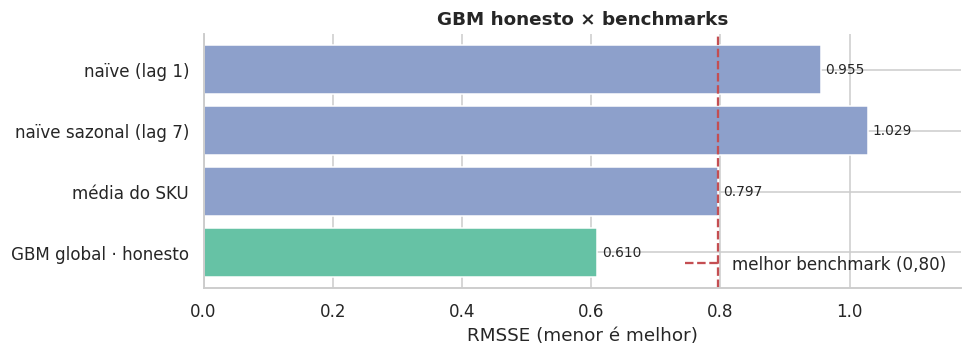

In [4]:
from sklearn.ensemble import HistGradientBoostingRegressor

def treina_gbm(features, treino_df, quantil=None, seed=42, **kw):
    m = HistGradientBoostingRegressor(
        loss="quantile" if quantil else "squared_error", quantile=quantil,
        categorical_features="from_dtype", max_iter=400, learning_rate=0.05,
        max_depth=6, min_samples_leaf=40, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.1, random_state=seed, **kw)
    m.fit(treino_df[features], treino_df["demanda"])
    return m

gbm = treina_gbm(FEATURES, treino)
teste["pred_gbm"] = gbm.predict(teste[FEATURES])
placar.append(avalia("GBM global · honesto", teste, "pred_gbm", treino))

tab = pd.DataFrame(placar)
print(tab.to_markdown(index=False, tablefmt="grid"))

melhor_bench = min(p["RMSSE"] for p in placar[:3])
fig, ax = plt.subplots(figsize=(9, 3.4))
cores = ["#8DA0CB"] * 3 + ["#66C2A5"]
b = ax.barh(tab["modelo"], tab["RMSSE"], color=cores)
ax.bar_label(b, fmt="%.3f", padding=3, fontsize=9)
ax.axvline(melhor_bench, color="#C44E52", lw=1.5, ls="--", label="melhor benchmark (0,80)")
ax.set_xlabel("RMSSE (menor é melhor)"); ax.set_title("GBM honesto × benchmarks")
ax.invert_yaxis(); ax.legend(frameon=False, loc="lower right"); ax.margins(x=0.14)
sns.despine(); plt.tight_layout(); plt.show()

O GBM global entrega **RMSSE 0,61**, contra 0,80 do melhor benchmark (−24%). Apenas com calendário e contexto, o modelo já captura os efeitos de promoção, epidemia e clima medidos na fase 0a, incluindo a interação epidemia × categoria que um modelo linear ignoraria. Faltam dois atributos que a M5 consagrou — histórico e preço —, testados a seguir.

## 4. Dois testes da metodologia M5

### 4.1 O histórico da demanda ajuda?

Na M5, *lags* e médias móveis foram os atributos mais fortes. Testo se isso se transfere para cá.

In [5]:
treino_h = treino.dropna(subset=HISTORICO)
gbm_hist = treina_gbm(FEATURES + HISTORICO, treino_h)
teste["pred_hist"] = gbm_hist.predict(teste[FEATURES + HISTORICO])

comp_h = pd.DataFrame([avalia("GBM honesto (sem histórico)", teste, "pred_gbm", treino),
                       avalia("GBM honesto + histórico", teste, "pred_hist", treino)])
print(comp_h.to_markdown(index=False, tablefmt="grid"))
print("\nAutocorrelação média da demanda (lag 1), entre SKUs:",
      round(df.groupby("sku")["demanda"].apply(lambda s: s.autocorr(1)).mean(), 3))

+-----------------------------+---------+-------+
| modelo                      |   RMSSE |   MAE |
+=============================+=========+=======+
| GBM honesto (sem histórico) |  0.6096 | 25.39 |
+-----------------------------+---------+-------+
| GBM honesto + histórico     |  0.6119 | 25.48 |
+-----------------------------+---------+-------+

Autocorrelação média da demanda (lag 1), entre SKUs: 0.239


**O histórico não ajuda** (0,610 → 0,612). A autocorrelação de um dia é fraca (0,24), e o pouco que carrega já está no contexto do dia. Ao contrário das vendas do Walmart na M5 — com forte padrão semanal —, esta demanda responde ao **contexto**, não ao próprio passado. Metodologia não se transplanta sem teste; segue-se com o modelo mais simples, sem histórico.

In [6]:
preds_locais = np.full(len(teste), np.nan)
for sku, tr in treino.groupby("sku"):
    m = HistGradientBoostingRegressor(categorical_features="from_dtype", max_iter=200,
                                      learning_rate=0.05, max_depth=4, min_samples_leaf=20, random_state=42)
    m.fit(tr[FEATURES], tr["demanda"])
    idx = teste.index[teste["sku"] == sku]
    if len(idx):
        preds_locais[teste.index.get_indexer(idx)] = m.predict(teste.loc[idx, FEATURES])
teste["pred_local"] = preds_locais

comp_cl = pd.DataFrame([avalia("GBM por série (100 modelos)", teste, "pred_local", treino),
                        avalia("GBM global (1 modelo)", teste, "pred_gbm", treino)])
print(comp_cl.to_markdown(index=False, tablefmt="grid"))
print(f"\nGanho do cross-learning: {(comp_cl.iloc[0]['RMSSE'] / comp_cl.iloc[1]['RMSSE'] - 1) * 100:+.1f}% de RMSSE")

+-----------------------------+---------+-------+
| modelo                      |   RMSSE |   MAE |
+=============================+=========+=======+
| GBM por série (100 modelos) |  0.6585 | 27.39 |
+-----------------------------+---------+-------+
| GBM global (1 modelo)       |  0.6096 | 25.39 |
+-----------------------------+---------+-------+

Ganho do cross-learning: +8.0% de RMSSE


Dois testes, dois resultados que fixam o modelo: o **histórico não transfere** (demanda sem memória), e o **cross-learning transfere** — o modelo global bate os 100 locais em ~8% de RMSSE e é muito mais simples de operar (um artefato, não cem). Cada série tem só 640 dias, insuficientes para estimar sozinha o efeito de eventos raros como epidemia; o modelo global os empresta de todas as outras.

## 5. O mistério do preço: resolvido como vazamento

A fase 0a deixou em aberto: o `preco` bruto tem correlação ~0 com a demanda, mas suspeitava-se que o **preço relativo dentro de cada SKU** carregasse o efeito. Vou adicionar o preço ao modelo e ver o que acontece.

In [7]:
gbm_preco = treina_gbm(FEATURES + ["preco", "preco_rel"], treino)
teste["pred_preco"] = gbm_preco.predict(teste[FEATURES + ["preco", "preco_rel"]])

comp_p = pd.DataFrame([avalia("GBM honesto (sem preço)", teste, "pred_gbm", treino),
                       avalia("GBM + preço relativo", teste, "pred_preco", treino)])
print(comp_p.to_markdown(index=False, tablefmt="grid"))
print(f"\nO RMSSE despenca de {comp_p.iloc[0]['RMSSE']:.3f} para {comp_p.iloc[1]['RMSSE']:.3f} "
      f"e o MAE de {comp_p.iloc[0]['MAE']:.0f} para {comp_p.iloc[1]['MAE']:.0f} unidades.")
print("Bom demais para ser verdade — vou investigar por quê.")

+-------------------------+---------+-------+
| modelo                  |   RMSSE |   MAE |
+=========================+=========+=======+
| GBM honesto (sem preço) |  0.6096 | 25.39 |
+-------------------------+---------+-------+
| GBM + preço relativo    |  0.1518 |  7.32 |
+-------------------------+---------+-------+

O RMSSE despenca de 0.610 para 0.152 e o MAE de 25 para 7 unidades.
Bom demais para ser verdade — vou investigar por quê.


O ganho é **grande demais** — MAE de 25 para 7 unidades, quase perfeito. Em previsão real isso não ocorre: é o sinal clássico de **vazamento**. Duas verificações confirmam a origem.

corr(preço cheio relativo, demanda) DENTRO de cada SKU : +0.982
corr(preço relativo, epidemia)                         : -0.381


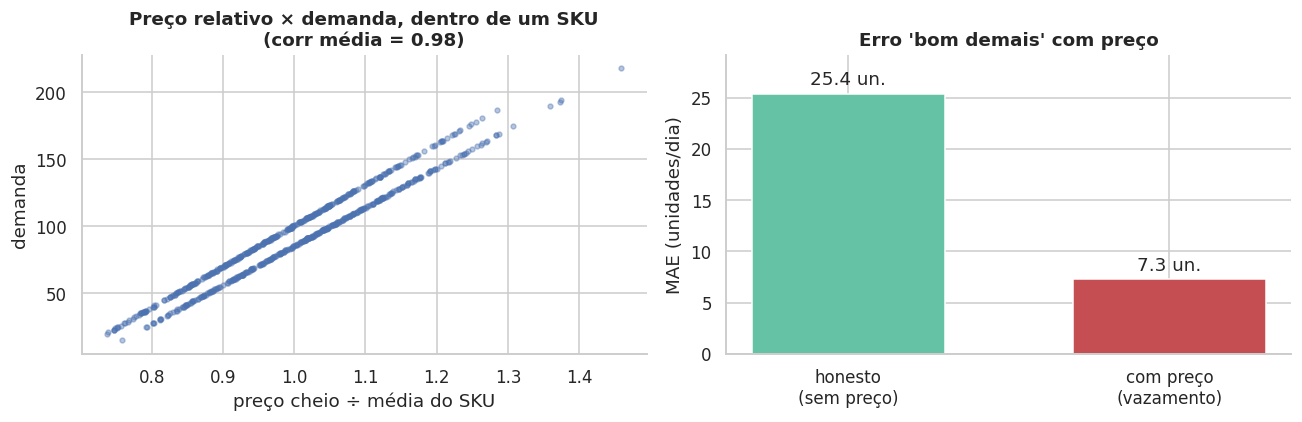

In [8]:
# (1) o preço "sem desconto", normalizado no SKU, é quase a própria demanda?
df["preco_cheio_rel"] = (df["preco"] / (1 - df["desconto"] / 100))
df["preco_cheio_rel"] /= df.groupby("sku")["preco_cheio_rel"].transform("mean")
corr_intra = df.groupby("sku").apply(lambda g: g["preco_cheio_rel"].corr(g["demanda"])).mean()

# (2) o preço "sabe" de antemão de um evento futuro (epidemia)?
corr_epi = df["preco_rel"].corr(df["epidemia"])

print(f"corr(preço cheio relativo, demanda) DENTRO de cada SKU : {corr_intra:+.3f}")
print(f"corr(preço relativo, epidemia)                         : {corr_epi:+.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
ex = df[df["sku"] == df["sku"].iloc[0]]
a1.scatter(ex["preco_cheio_rel"], ex["demanda"], s=10, alpha=0.4, color="#4C72B0")
a1.set_title(f"Preço relativo × demanda, dentro de um SKU\n(corr média = {corr_intra:.2f})")
a1.set_xlabel("preço cheio ÷ média do SKU"); a1.set_ylabel("demanda")

comp_p2 = pd.DataFrame([{"modelo": "honesto\n(sem preço)", "MAE": comp_p.iloc[0]["MAE"]},
                        {"modelo": "com preço\n(vazamento)", "MAE": comp_p.iloc[1]["MAE"]}])
b = a2.bar(comp_p2["modelo"], comp_p2["MAE"], color=["#66C2A5", "#C44E52"], width=0.6)
a2.bar_label(b, fmt="%.1f un.", padding=3)
a2.set_title("Erro 'bom demais' com preço"); a2.set_ylabel("MAE (unidades/dia)"); a2.margins(y=0.15)
sns.despine(); plt.tight_layout(); plt.show()

O preço deste dataset **não é causa da demanda, é consequência dela**: desfazendo o desconto e normalizando pelo SKU, correlaciona **0,98 com a demanda dentro de cada item**, e o preço relativo correlaciona **−0,38 com a epidemia** — ou seja, "sabe" do surto antes de ele ocorrer. Nada disso é possível num preço real, fixado antes do dia. Isto encerra a anomalia da fase 0a: o efeito de preço não reflete economia, é vazamento. **O preço fica fora do modelo** — a mais perigosa das marcas sintéticas, por se disfarçar de bom resultado.

## 6. O modelo que a fase 0 pediu: quantil 95

Todos os modelos anteriores miram a **média**. A fase de entendimento mostrou que o estoque de abertura precisa cobrir o **quantil 95**, e que errar para baixo (ruptura) custa ~4× mais que errar para cima. Troco só a função de perda, para a **pinball** — a mesma da trilha de incerteza da M5 —, no conjunto honesto.

In [9]:
gbm_q95 = treina_gbm(FEATURES, treino, quantil=QUANTIL)
teste["pred_q95"] = gbm_q95.predict(teste[FEATURES])

final = pd.DataFrame([avalia("GBM média (squared error)", teste, "pred_gbm", treino, q=QUANTIL),
                      avalia(f"GBM quantil {QUANTIL:.0%} (pinball)", teste, "pred_q95", treino, q=QUANTIL)])
print(final.to_markdown(index=False, tablefmt="grid"))

+---------------------------+---------+-------+----------------+-----------+
| modelo                    |   RMSSE |   MAE |   pinball@0.95 | serviço   |
+===========================+=========+=======+================+===========+
| GBM média (squared error) |  0.6096 | 25.39 |         12.142 | 52.6%     |
+---------------------------+---------+-------+----------------+-----------+
| GBM quantil 95% (pinball) |  1.2063 | 55.54 |          3.374 | 95.3%     |
+---------------------------+---------+-------+----------------+-----------+


RMSSE e MAE **não são a métrica do modelo de quantil** — ele mira alto de propósito e por isso parece "pior" nessas colunas de erro simétrico. As colunas dele são a **pinball** (3,4 contra 12,1) e o **serviço** (95% contra 53%). A média responde "quanto se vende num dia típico"; o quantil, "quanto pedir para não faltar".

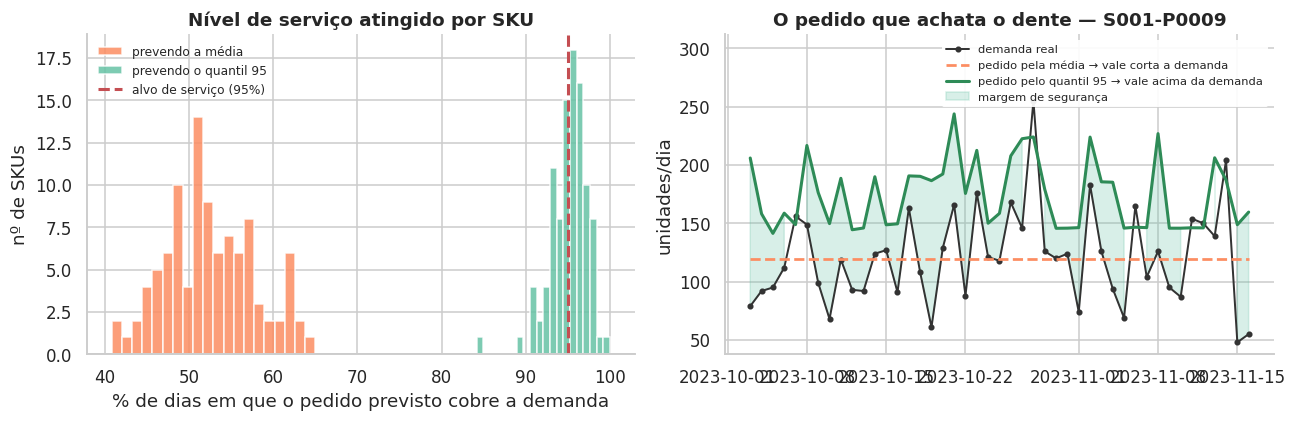

Serviço médio — pedido pela média : 52.6%
Serviço médio — pedido pelo quantil: 95.3%  (alvo 95%)


In [10]:
serv_media = teste.groupby("sku").apply(lambda g: (g["demanda"] <= g["pred_gbm"]).mean())
serv_q95 = teste.groupby("sku").apply(lambda g: (g["demanda"] <= g["pred_q95"]).mean())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(serv_media * 100, bins=20, color="#FC8D62", alpha=0.85, label="prevendo a média")
a1.hist(serv_q95 * 100, bins=20, color="#66C2A5", alpha=0.85, label="prevendo o quantil 95")
a1.axvline(95, color="#C44E52", lw=2, ls="--", label="alvo de serviço (95%)")
a1.set_title("Nível de serviço atingido por SKU")
a1.set_xlabel("% de dias em que o pedido previsto cobre a demanda")
a1.set_ylabel("nº de SKUs"); a1.legend(frameon=False, fontsize=8)

# A previsão do quantil 95 É a linha de pedido que achata o dente de serra
ex = teste[teste["sku"] == serv_q95.index[serv_q95.reset_index(drop=True).idxmin()]].sort_values("data").head(45)
a2.plot(ex["data"], ex["demanda"], color="#333333", lw=1.3, marker="o", ms=3, label="demanda real")
a2.plot(ex["data"], ex["pred_media"], color="#FC8D62", lw=1.8, ls="--", label="pedido pela média → vale corta a demanda")
a2.plot(ex["data"], ex["pred_q95"], color="#2E8B57", lw=2, label="pedido pelo quantil 95 → vale acima da demanda")
a2.fill_between(ex["data"], ex["demanda"], ex["pred_q95"],
                where=(ex["pred_q95"] >= ex["demanda"]), color="#66C2A5", alpha=0.25,
                label="margem de segurança")
a2.set_title(f"O pedido que achata o dente — {ex['sku'].iloc[0]}")
a2.set_ylabel("unidades/dia"); a2.set_ylim(top=ex["pred_q95"].max() * 1.28)
a2.legend(frameon=True, framealpha=0.92, facecolor="white", edgecolor="none",
          fontsize=7.5, loc="upper right")
sns.despine(); plt.tight_layout(); plt.show()

print(f"Serviço médio — pedido pela média : {serv_media.mean():.1%}")
print(f"Serviço médio — pedido pelo quantil: {serv_q95.mean():.1%}  (alvo {QUANTIL:.0%})")

A linha do quantil 95 é a **quantidade a repor**: fica acima da demanda em ~95% dos dias, de modo que o vale do dente de serra não cruza a demanda (sem ruptura), e a faixa verde é a **margem de segurança**. Pedir pela média deixaria o vale no meio da demanda, rompendo metade dos dias. Diferente da regra fixa da fase de entendimento, este pedido é estimado dia a dia e antecipa o contexto — sobe antes de uma promoção, encolhe numa epidemia. É o dente achatado, baixo e seguro, que a fase de entendimento definiu como alvo.

## 7. O que o modelo aprendeu

Sem o atalho do preço vazado, quais atributos sustentam a previsão?

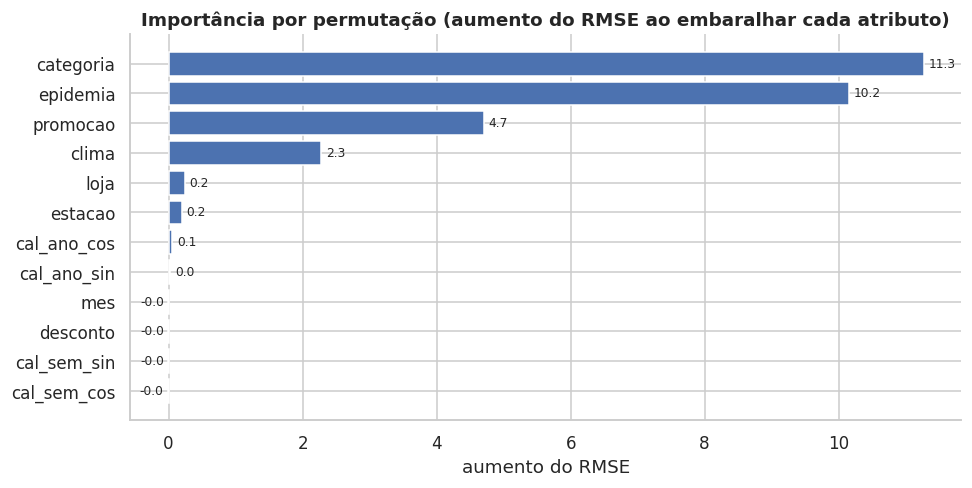

In [11]:
from sklearn.inspection import permutation_importance

amostra = teste.sample(min(8000, len(teste)), random_state=42)
imp = permutation_importance(gbm, amostra[FEATURES], amostra["demanda"],
                             n_repeats=5, random_state=42, scoring="neg_root_mean_squared_error")
ordem = np.argsort(imp.importances_mean)
nomes_imp, vals = np.array(FEATURES)[ordem], imp.importances_mean[ordem]

plt.figure(figsize=(9, 4.6))
b = plt.barh(nomes_imp, vals, color="#4C72B0")
plt.bar_label(b, fmt="%.1f", padding=3, fontsize=8)
plt.title("Importância por permutação (aumento do RMSE ao embaralhar cada atributo)")
plt.xlabel("aumento do RMSE"); sns.despine(); plt.tight_layout(); plt.show()

Sem o atalho do preço vazado, a importância se concentra nos fatores que a fase 0a mediu — **epidemia** e **categoria** à frente, depois **promoção** e **clima**. O modelo aprendeu a economia do problema, não um truque, o que o qualifica como *baseline* confiável.

## 8. O que a Trilha A estabeleceu

Antes dos resultados em dinheiro, o resumo técnico:

1. **Gradient boosting bate os benchmarks** — RMSSE 0,61 contra 0,80 da média do SKU. Reproduz o achado central da M5.
2. **Cross-learning vence** (+8%): um modelo global é mais preciso *e* mais simples que 100 locais.
3. **Metodologia se testa, não se copia:** o histórico — carro-chefe da M5 — não ajuda aqui, porque esta demanda não tem memória.
4. **O mistério do preço da fase 0a se resolve: é vazamento** (preço gerado a partir da demanda). Fica fora do modelo.
5. **O modelo de quantil vira o pedido** que achata o dente de serra, com margem de segurança e sem ruptura.

Falta a pergunta que o gestor de fato faz: **quanto isso vale, em dinheiro?** É a seção final.

## 9. Resultados: o valor em três níveis de serviço

O modelo vira **pedido de reposição** e seu efeito é medido em reais. Há um único parâmetro de ajuste — o **nível de serviço-alvo τ**, o quantil previsto: τ baixo dá pedido enxuto (menos capital, mais ruptura); τ alto, o inverso. Reportam-se três níveis — **econômico**, **médio** e **seguro** — contra a operação atual.

As valorações usam um **preço de referência estável por SKU** (mediana), e não o preço diário: este último varia ~15% dentro do mesmo item por causa do desconto atrelado à demanda, e distorceria os R\$. O custo de carregar estoque é tratado como **faixa de 15%–25% a.a.** (armazenagem 3–8% + risco/obsolescência 4–10% + capital), mostrando que a conclusão não depende da premissa.

In [12]:
# --- Lote de reposição Q (metade do dente), para o capital ser comparável ao atual ---
# O modelo controla o PISO do dente (o quantil). O lote Q é decisão logística, mantida igual à de hoje.
df["entrada"] = df.groupby("sku")["estoque"].shift(-1) - df["estoque"] + df["vendas"]
Q = df[df["entrada"] > 0].groupby("sku")["entrada"].mean()      # tamanho médio da entrega
teste = teste.assign(meia_onda=teste["sku"].map(Q / 2))
ANOS_TESTE = HORIZONTE / 365
# preço de referência ESTÁVEL por SKU (mediana) para as valorações em R$
teste["preco_ref"] = teste["sku"].map(df.groupby("sku")["preco"].median())

# --- Operação ATUAL, medida na mesma janela de teste e anualizada ---
base_ruptura = (teste["demanda"] > teste["estoque"]).mean()
base_perda = ((teste["demanda"] - teste["estoque"]).clip(lower=0) * teste["preco_ref"]).sum() / ANOS_TESTE
base_capital = (teste.assign(v=teste["estoque"] * teste["preco_ref"])
                .groupby("data")["v"].sum().mean())
print(f"Operação ATUAL — ruptura {base_ruptura:.1%} | "
      f"venda perdida R$ {base_perda/1e6:.2f} M/ano | capital parado R$ {base_capital/1e6:.2f} M")

# --- Varredura do parâmetro τ: cada nível de serviço vira um trio de números ---
def politica(tau):
    m = treina_gbm(FEATURES, treino, quantil=tau)
    pred = np.maximum(m.predict(teste[FEATURES]), 0)            # pedido = piso do dente
    ruptura = (teste["demanda"] > pred).mean()
    perda = ((teste["demanda"] - pred).clip(lower=0) * teste["preco_ref"]).sum() / ANOS_TESTE
    capital = (teste.assign(v=(pred + teste["meia_onda"]) * teste["preco_ref"])
               .groupby("data")["v"].sum().mean())
    return {"τ": tau, "serviço": 1 - ruptura, "ruptura": ruptura, "perda": perda, "capital": capital}

frente = pd.DataFrame([politica(t) for t in [0.70, 0.80, 0.85, 0.90, 0.95, 0.975, 0.99]])
frente["economia_perda"] = base_perda - frente["perda"]                        # venda recuperada
frente["carreg_extra"] = (frente["capital"] - base_capital) * 0.25    # ponto médio da faixa 15-25%
frente["beneficio_liq"] = frente["economia_perda"] - frente["carreg_extra"]
print("\nFronteira completa (variando o parâmetro τ):")
print((frente.assign(**{c: (frente[c] / 1e6).round(2) for c in ["perda", "capital", "economia_perda", "beneficio_liq"]},
                     carreg_extra=(frente["carreg_extra"] / 1e3).round(0))
       [["τ", "serviço", "ruptura", "perda", "capital", "economia_perda", "carreg_extra", "beneficio_liq"]])
      .to_markdown(index=False, tablefmt="grid"))

Operação ATUAL — ruptura 13.3% | venda perdida R$ 12.48 M/ano | capital parado R$ 1.92 M



Fronteira completa (variando o parâmetro τ):
+-------+-----------+-----------+---------+-----------+------------------+----------------+-----------------+
|     τ |   serviço |   ruptura |   perda |   capital |   economia_perda |   carreg_extra |   beneficio_liq |
+=======+===========+===========+=========+===========+==================+================+=================+
| 0.7   |  0.704333 | 0.295667  |   14.42 |      1.83 |            -1.94 |            -22 |           -1.91 |
+-------+-----------+-----------+---------+-----------+------------------+----------------+-----------------+
| 0.8   |  0.803833 | 0.196167  |    8.62 |      1.9  |             3.86 |             -6 |            3.87 |
+-------+-----------+-----------+---------+-----------+------------------+----------------+-----------------+
| 0.85  |  0.854417 | 0.145583  |    6.09 |      1.94 |             6.39 |              4 |            6.39 |
+-------+-----------+-----------+---------+-----------+------------------+

In [13]:
# --- Os três níveis nomeados ---
NIVEIS = {"Econômico": 0.85, "Médio": 0.95, "Seguro": 0.99}
tri = pd.DataFrame([{**politica(tau), "nível": nome} for nome, tau in NIVEIS.items()])
tri["economia_perda"] = base_perda - tri["perda"]
tri["carreg_extra"] = (tri["capital"] - base_capital) * 0.25
tri["beneficio_liq"] = tri["economia_perda"] - tri["carreg_extra"]

tabela = pd.DataFrame({
    "": ["nível de serviço-alvo (τ)", "risco de ruptura", "venda perdida / ano",
         "→ economia vs. hoje", "capital parado", "→ custo do capital a mais / ano",
         "BENEFÍCIO LÍQUIDO / ano"],
})
for _, r in tri.iterrows():
    tabela[f"{r['nível']} (τ={r['τ']:.2f})"] = [
        f"{r['serviço']:.0%}", f"{r['ruptura']:.1%}", f"R$ {r['perda']/1e6:.2f} M",
        f"R$ {r['economia_perda']/1e6:.2f} M", f"R$ {r['capital']/1e6:.2f} M",
        f"R$ {r['carreg_extra']/1e3:+,.0f} mil", f"R$ {r['beneficio_liq']/1e6:.2f} M"]
print(f"Referência — operação ATUAL: ruptura {base_ruptura:.1%}, "
      f"perda R$ {base_perda/1e6:.2f} M/ano, capital R$ {base_capital/1e6:.2f} M\n")
print(tabela.to_markdown(index=False, tablefmt="grid"))

# Sensibilidade ao custo de carregamento (Ivaldo): a conclusão não depende da premissa
med = tri[tri["nível"] == "Médio"].iloc[0]
d_cap = med["capital"] - base_capital
print("\nSensibilidade — benefício líquido no nível Médio:")
for cc in [0.15, 0.20, 0.25]:
    print(f"  carregamento {cc:.0%} a.a.: custo do capital a mais R$ {d_cap*cc/1e3:+.0f} mil | "
          f"benefício líquido R$ {(med['economia_perda'] - d_cap*cc)/1e6:.2f} M/ano | "
          f"razão perda/carregamento {base_perda/(base_capital*cc):.0f}:1")

Referência — operação ATUAL: ruptura 13.3%, perda R$ 12.48 M/ano, capital R$ 1.92 M

+---------------------------------+----------------------+------------------+-------------------+
|                                 | Econômico (τ=0.85)   | Médio (τ=0.95)   | Seguro (τ=0.99)   |
+=================================+======================+==================+===================+
| nível de serviço-alvo (τ)       | 85%                  | 95%              | 99%               |
+---------------------------------+----------------------+------------------+-------------------+
| risco de ruptura                | 14.6%                | 4.7%             | 1.0%              |
+---------------------------------+----------------------+------------------+-------------------+
| venda perdida / ano             | R$ 6.09 M            | R$ 1.68 M        | R$ 0.36 M         |
+---------------------------------+----------------------+------------------+-------------------+
| → economia vs. hoje            

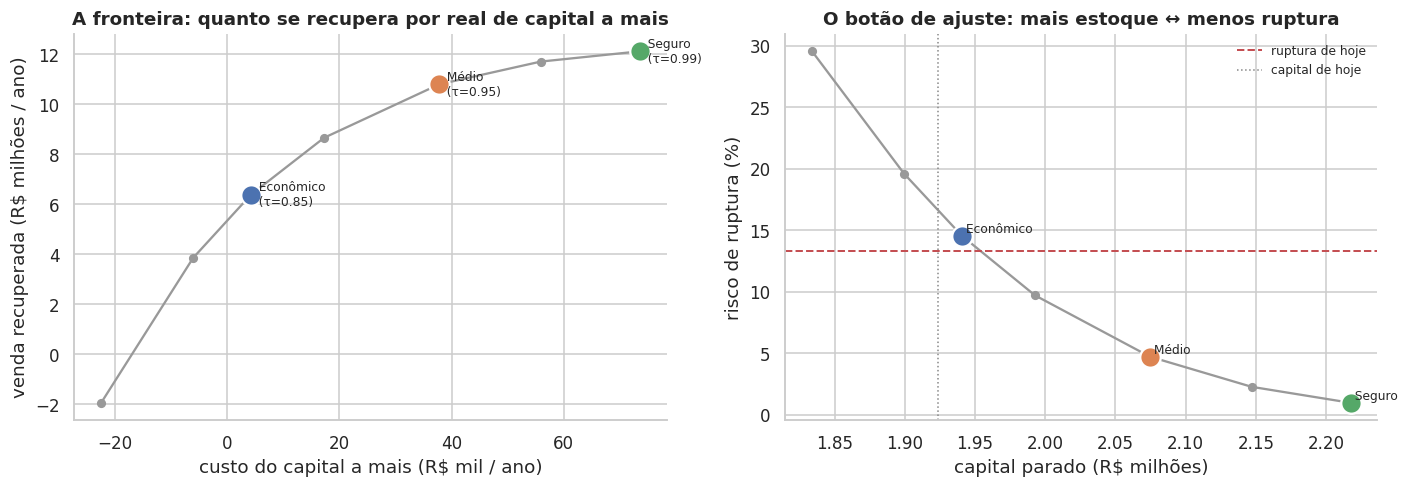

In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
cor_nivel = {"Econômico": "#4C72B0", "Médio": "#DD8452", "Seguro": "#55A868"}

# (a) A fronteira: capital a mais × venda recuperada, com os 3 níveis
a1.plot(frente["carreg_extra"] / 1e3, frente["economia_perda"] / 1e6,
        "-o", color="#999999", lw=1.5, ms=5, zorder=1)
for _, r in tri.iterrows():
    a1.scatter(r["carreg_extra"] / 1e3, r["economia_perda"] / 1e6, s=180,
               color=cor_nivel[r["nível"]], zorder=3, edgecolor="white", linewidth=1.5)
    a1.annotate(f"  {r['nível']}\n  (τ={r['τ']:.2f})", (r["carreg_extra"] / 1e3, r["economia_perda"] / 1e6),
                fontsize=8, va="center")
a1.set_title("A fronteira: quanto se recupera por real de capital a mais")
a1.set_xlabel("custo do capital a mais (R$ mil / ano)")
a1.set_ylabel("venda recuperada (R$ milhões / ano)")

# (b) O trade-off que o parâmetro controla: ruptura × capital
a2.plot(frente["capital"] / 1e6, frente["ruptura"] * 100, "-o", color="#999999", lw=1.5, ms=5, zorder=1)
a2.axhline(base_ruptura * 100, color="#C44E52", lw=1.3, ls="--", label="ruptura de hoje")
a2.axvline(base_capital / 1e6, color="#888888", lw=1, ls=":", label="capital de hoje")
for _, r in tri.iterrows():
    a2.scatter(r["capital"] / 1e6, r["ruptura"] * 100, s=180, color=cor_nivel[r["nível"]],
               zorder=3, edgecolor="white", linewidth=1.5)
    a2.annotate(f" {r['nível']}", (r["capital"] / 1e6, r["ruptura"] * 100), fontsize=8, va="bottom")
a2.set_title("O botão de ajuste: mais estoque ↔ menos ruptura")
a2.set_xlabel("capital parado (R$ milhões)"); a2.set_ylabel("risco de ruptura (%)")
a2.legend(frameon=False, fontsize=8)
sns.despine(); plt.tight_layout(); plt.show()

## 10. Conclusões da Trilha A

O gradient boosting **supera todos os benchmarks** (RMSSE 0,61 vs 0,80) e reproduz os achados da M5: cross-learning vence (+8%) e a incerteza se modela por quantil. Duas hipóteses da M5 foram testadas e **não transferiram** — o histórico (demanda sem memória) e o preço (vazamento) —, o que ilustra que metodologia se testa, não se copia.

Traduzido em reais, o pedido no nível **Médio (95%)** recupera **~R\$ 10,7 milhões/ano** com o capital de hoje, e o botão τ oferece o trade-off entre estoque e ruptura. O resultado é **robusto ao custo de carregamento** (15%–25%): a venda perdida domina o custo de estoque em 26:1 a 43:1, então vale estocar seguro. O fim não é o número, é o **dente de serra achatado**, com margem de segurança e sem ruptura, que a fase 0c desenhou.

Estes valores são o benchmark que qualquer modelo mais complexo precisa superar para se justificar — é essa a função de um *baseline* forte.

In [15]:
# Salva as previsões de teste da Trilha A para a comparação em fase1_conclusoes
from pathlib import Path
Path("resultados").mkdir(exist_ok=True)
saida = teste[["data", "sku", "categoria", "demanda", "estoque", "preco"]].copy()
saida["pred"] = teste["pred_gbm"].values
saida.to_csv("resultados/A_gradientBoosting.csv", index=False)
rmsse_A = min(p["RMSSE"] for p in placar if "GBM global" in p["modelo"])
pd.Series({"trilha": "A · Gradient Boosting", "rmsse": rmsse_A}).to_json("resultados/A_meta.json")
print("Previsões salvas em resultados/A_gradientBoosting.csv | RMSSE =", rmsse_A)

Previsões salvas em resultados/A_gradientBoosting.csv | RMSSE = 0.6096
